# IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# LOAD CLEANED DATASET

In [2]:
df = pd.read_csv('cleaned_sample_data.csv')

# MENAMPILKAN 5 DATA PERTAMA

In [3]:
df.head()

,user_id,product_id,rating,timestamp
0,A1PSUH0U1FPQ6R,B002QXZPFE,4.0,2013-08-19
1,A23QSTB241NRF3,B0040HJOO2,1.0,2012-04-24
2,A1IU4JZFDZA9HJ,B004LRO7FW,5.0,2012-01-12
3,A1B2D4J8KF4DFN,B006DKEQL0,2.0,2013-05-10
4,A2SYLJAZO4SPA0,B00006G33N,4.0,2006-08-22


# INFORMASI DATASET

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155938 entries, 0 to 155937
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     155938 non-null  object 
 1   product_id  155938 non-null  object 
 2   rating      155938 non-null  float64
 3   timestamp   155938 non-null  object 
dtypes: float64(1), object(3)
memory usage: 4.8+ MB


# UKURAN DATASET

In [5]:
print("Ukuran dataset:")
print(df.shape)

Ukuran dataset:
(155938, 4)


# JUMLAH USER DAN PRODUK UNIK

In [6]:
unique_users = df['user_id'].nunique()
unique_products = df['product_id'].nunique()

print(f"Jumlah user unik: {unique_users}")
print(f"Jumlah produk unik: {unique_products}")

Jumlah user unik: 13345
Jumlah produk unik: 27447


# DISTRIBUSI RATING

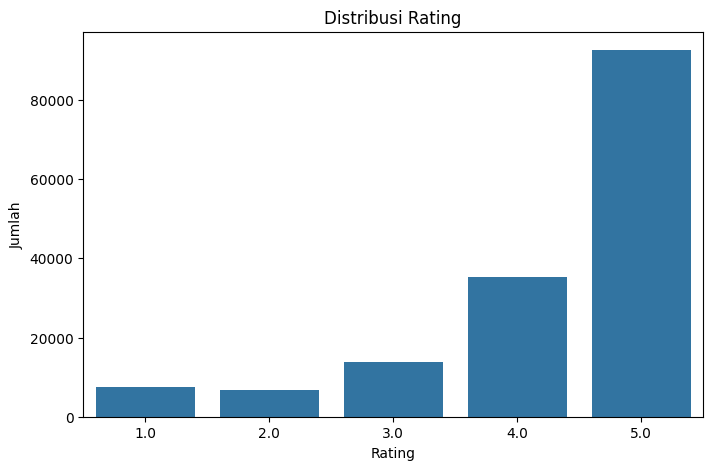

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=df
)

plt.title('Distribusi Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah')

plt.show()

# RATA-RATA RATING

In [8]:
average_rating = df['rating'].mean()

print(f"Rata-rata rating: {average_rating:.2f}")

Rata-rata rating: 4.28


Distribusi rating menunjukkan bahwa sebagian besar pengguna memberikan rating tinggi, khususnya rating 5, yang menandakan mayoritas pengguna merasa puas terhadap produk yang dibeli.

# TOP 10 PRODUK PALING BANYAK DIREVIEW

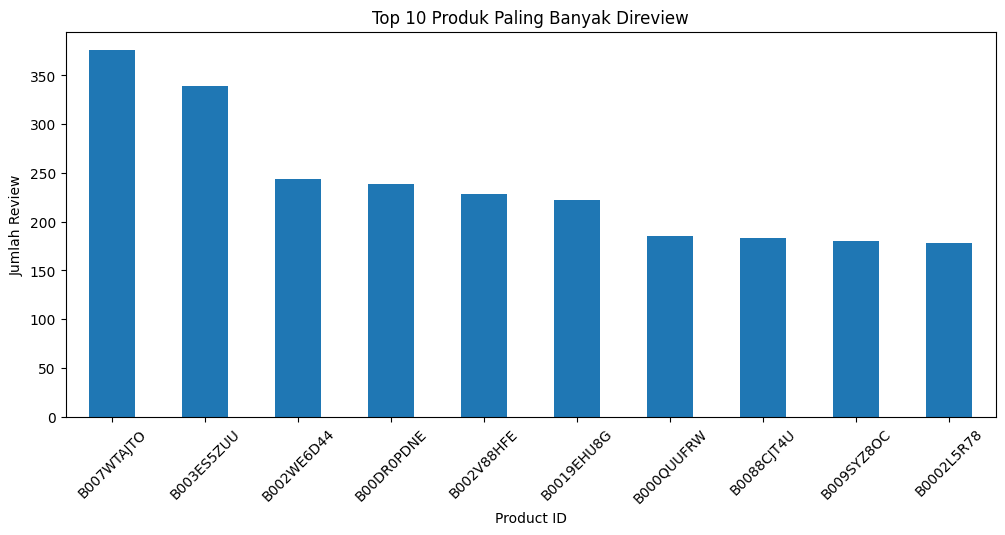

In [9]:
top_products = (
    df['product_id']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title('Top 10 Produk Paling Banyak Direview')
plt.xlabel('Product ID')
plt.ylabel('Jumlah Review')

plt.xticks(rotation=45)

plt.show()

# TOP 10 USER PALING AKTIF

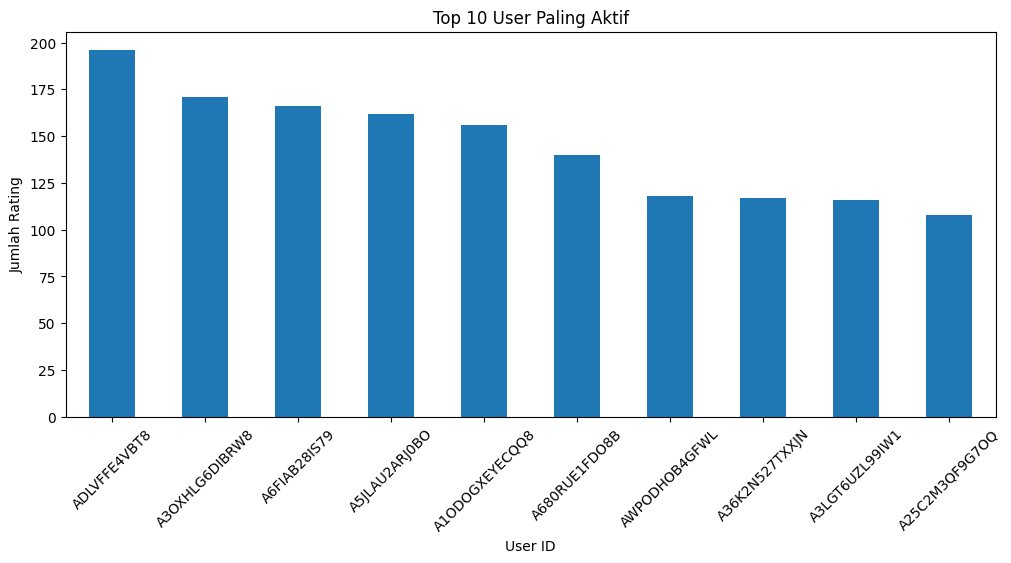

In [10]:
top_users = (
    df['user_id']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

top_users.plot(kind='bar')

plt.title('Top 10 User Paling Aktif')
plt.xlabel('User ID')
plt.ylabel('Jumlah Rating')

plt.xticks(rotation=45)

plt.show()

# DISTRIBUSI JUMLAH RATING PER USER

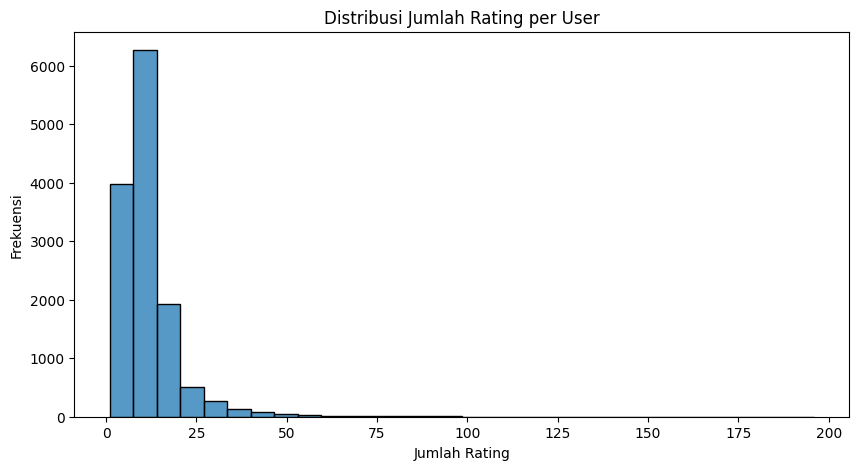

In [11]:
user_rating_counts = (
    df.groupby('user_id')['rating']
    .count()
)

plt.figure(figsize=(10,5))

sns.histplot(
    user_rating_counts,
    bins=30
)

plt.title('Distribusi Jumlah Rating per User')
plt.xlabel('Jumlah Rating')
plt.ylabel('Frekuensi')

plt.show()

# DISTRIBUSI JUMLAH RATING PER PRODUK

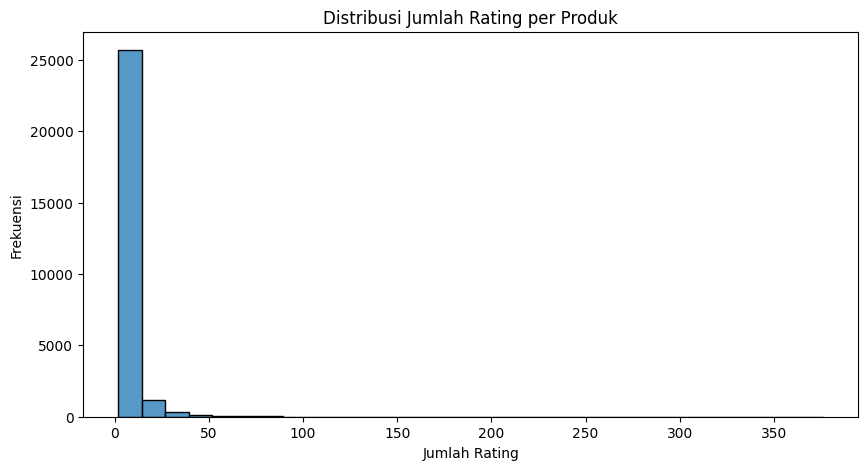

In [12]:
product_rating_counts = (
    df.groupby('product_id')['rating']
    .count()
)

plt.figure(figsize=(10,5))

sns.histplot(
    product_rating_counts,
    bins=30
)

plt.title('Distribusi Jumlah Rating per Produk')
plt.xlabel('Jumlah Rating')
plt.ylabel('Frekuensi')

plt.show()

# CEK SPARSITY DATASET

In [13]:
num_interactions = len(df)

sparsity = (
    1 -
    (
        num_interactions /
        (unique_users * unique_products)
    )
) * 100

print(f"Sparsity dataset: {sparsity:.6f}%")

Sparsity dataset: 99.957427%


# KONVERSI TIMESTAMP

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# EKSTRAK TAHUN REVIEW

In [15]:
df['year'] = df['timestamp'].dt.year

# DISTRIBUSI TAHUN REVIEW

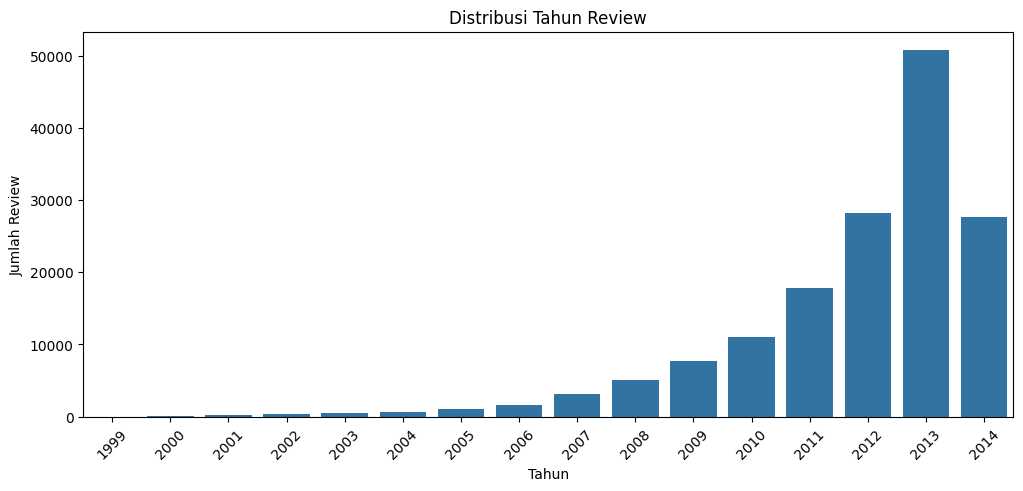

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='year',
    data=df,
    order=sorted(df['year'].unique())
)

plt.title('Distribusi Tahun Review')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Review')

plt.xticks(rotation=45)

plt.show()

# TOP 10 PRODUK DENGAN RATING TERTINGGI

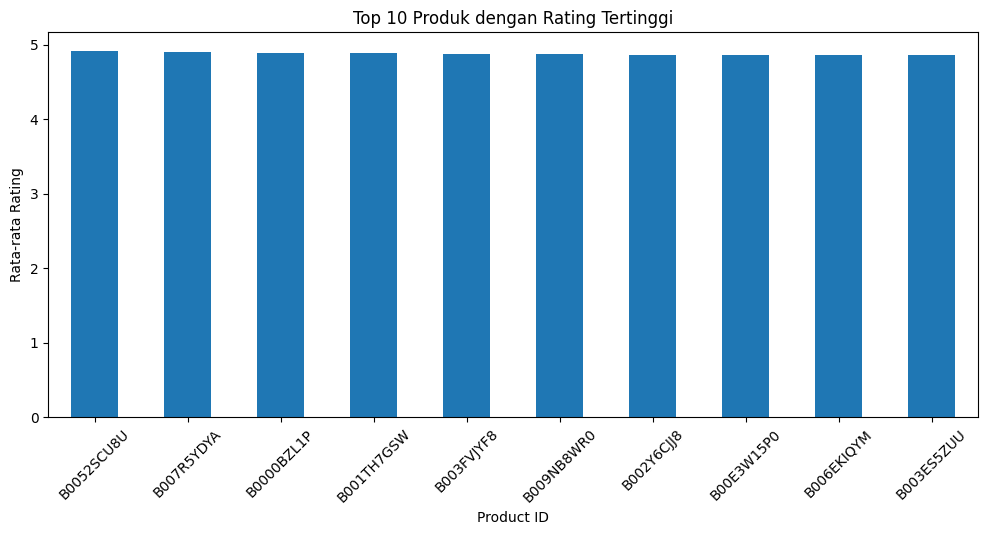

In [19]:
product_stats = df.groupby('product_id').agg({
    'rating': ['mean', 'count']
})

product_stats.columns = ['avg_rating', 'rating_count']

filtered_products = product_stats[
    product_stats['rating_count'] >= 50
]

top_rated_products = (
    filtered_products['avg_rating']
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_rated_products.plot(kind='bar')

plt.title('Top 10 Produk dengan Rating Tertinggi')
plt.xlabel('Product ID')
plt.ylabel('Rata-rata Rating')

plt.xticks(rotation=45)

plt.show()

# DISTRIBUSI RATA-RATA RATING PRODUK

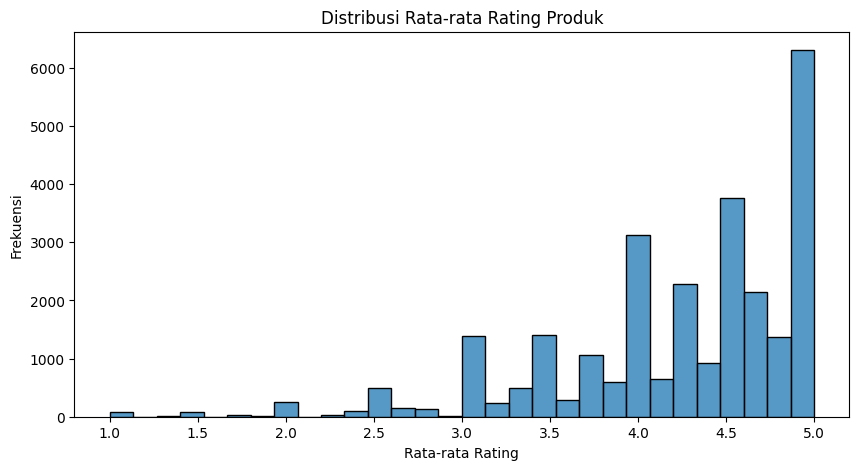

In [18]:
avg_product_rating = (
    df.groupby('product_id')['rating']
    .mean()
)

plt.figure(figsize=(10,5))

sns.histplot(
    avg_product_rating,
    bins=30
)

plt.title('Distribusi Rata-rata Rating Produk')
plt.xlabel('Rata-rata Rating')
plt.ylabel('Frekuensi')

plt.show()

# INSIGHT SEMENTARA:

1. Dataset hasil cleaning memiliki 155.938 interaksi,
   dengan 13.345 pengguna unik dan 27.447 produk unik.

2. Rating 5 mendominasi dataset, menunjukkan bahwa
   mayoritas pengguna memberikan ulasan positif terhadap produk.

3. Aktivitas pengguna tidak merata, dimana sebagian besar
   user hanya memberikan sedikit rating, sedangkan beberapa
   user sangat aktif dalam memberikan review.

4. Distribusi review produk menunjukkan pola long-tail,
   dimana sebagian kecil produk memiliki jumlah review sangat tinggi,
   sementara mayoritas produk hanya memiliki sedikit review.

5. Aktivitas review mengalami peningkatan signifikan pada
   tahun 2011–2014, dengan puncak review terjadi pada tahun 2013.

6. Dataset memiliki sparsity sebesar 99.96%, yang merupakan
   karakteristik umum pada sistem rekomendasi e-commerce karena
   pengguna hanya berinteraksi dengan sebagian kecil produk yang tersedia.